In [1]:
import os, csv
import numpy as np
import torch
import matplotlib.pyplot as plt

from utils.load_and_clean_real_data import load_and_clean_real_data
from utils.dataclass_TL import TimeSeriesInferenceDataset

# ---- paths ----
DATA_PATH = "synthetic_data/synthetic_data_TL.csv"
KAPPA_NPZ = "synthetic_data/kappa_samples_Exp1_4gauss.npz"

CUTOFF = 300
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

# ---- truth (synthetic generation) ----
ALPHA_TRUE = 0.05
MU_TRUE    = 0.5
D_TRUE     = 0.12
RHO_TRUE   = 0.1

truth = (ALPHA_TRUE, MU_TRUE, D_TRUE, RHO_TRUE)

# ---- 1D grids ----
ALPHAS = np.linspace(0.0, 0.1, 11)[1:]   # 10
MUS    = np.linspace(0.2, 1.0, 11)[1:]  # 10
DS     = np.linspace(0.0, 0.2, 11)[1:]  # 10
RHOS   = np.linspace(0.0, 0.4, 11)[1:]  # 10

DEVICE: cuda


In [2]:
torch.manual_seed(15)
np.random.seed(15)

df = load_and_clean_real_data(DATA_PATH, cutoff=CUTOFF)
ts     = torch.tensor(df["Day"].values * 24)       # hours
counts = torch.tensor(df["Counts"].values)
dils   = torch.tensor(df["Dilution"].values)

kappa_np = np.load(KAPPA_NPZ)["kappa_samples"]

dataset = TimeSeriesInferenceDataset(
    ts=ts,
    counts=counts,
    dils=dils,
    kappa_samples=kappa_np,
    cutoff=CUTOFF,
    device=DEVICE,
)

print(f"Loaded dataset with {dataset.ndatapoints} points; timepoints={len(dataset.times)}")

[WARN] Missing columns skipped: CFU_2
[INFO] Using dilutions: [22, 222, 2222]
[INFO] Loaded 375 rows from synthetic_data/synthetic_data_TL.csv
[INFO] Retained 375 rows with valid CFU entries.
[INFO] Dropped 0 rows with no valid CFU values at any dilution.
Dataset loaded: 375 points, 5 timepoints.
Loaded dataset with 375 points; timepoints=5


In [3]:
# =========================
# Likelihood wrapper
# =========================

def loglike_theta(dataset, alpha, mu, d, rho):
    alpha = torch.as_tensor(alpha, device=dataset.device, dtype=torch.float32)
    mu    = torch.as_tensor(mu,    device=dataset.device, dtype=torch.float32)
    d     = torch.as_tensor(d,     device=dataset.device, dtype=torch.float32)
    rho   = torch.as_tensor(rho,   device=dataset.device, dtype=torch.float32)
    theta = torch.stack([alpha, mu, d, rho])  # (4,)
    with torch.no_grad():
        ll = dataset.loglike(theta)
    return float(ll.detach().cpu())

In [4]:
# Run one 1D sweep (generic helper)
def run_1d(which: str, grid: np.ndarray, truth):
    a0, m0, d0, r0 = truth
    xs = []
    lls = []
    best = (-np.inf, None)  # (ll, x)

    for x in grid:
        a, m, d, r = a0, m0, d0, r0
        if which == "alpha": a = float(x)
        elif which == "mu":  m = float(x)
        elif which == "d":   d = float(x)
        elif which == "rho": r = float(x)
        else:
            raise ValueError("which must be one of: alpha, mu, d, rho")

        ll = loglike_theta(dataset, a, m, d, r)
        print(ll)
        xs.append(float(x))
        lls.append(ll)
        if ll > best[0]:
            best = (ll, float(x))

    return np.array(xs), np.array(lls), best


In [5]:
x_a, ll_a, best_a = run_1d("alpha", ALPHAS, truth)
x_m, ll_m, best_m = run_1d("mu",    MUS,    truth)
x_d, ll_d, best_d = run_1d("d",     DS,     truth)
x_r, ll_r, best_r = run_1d("rho",   RHOS,   truth)

print("Truth:", truth)
print("[alpha] best ll:", best_a[0], "at alpha =", best_a[1])
print("[mu]    best ll:", best_m[0], "at mu    =", best_m[1])
print("[d]     best ll:", best_d[0], "at d     =", best_d[1])
print("[rho]   best ll:", best_r[0], "at rho   =", best_r[1])

-2408.713720415928
-2230.9666171525123
-2146.110550306119
-2096.9980425414374
-2065.336162473691
-2047.2260059037349
-2036.5893804860223
-2031.552959101412
-2029.0973887356586
-2031.0835540568642
-4656.036839981942
-2290.855803635721
-2084.7068668127895
-2063.719620049892
-2064.1545761474886
-2068.3738916033017
-2073.571082825272
-2077.195821351305
-2080.4768429266546
-2084.7572904914136
-2049.301287225321
-2049.3021262258294
-2051.684987683723
-2054.3649141095557
-2059.6205670821155
-2063.644531165853
-2073.0375473462873
-2085.1985558608803
-2101.795828221293
-2122.7172609275904
-2090.0840022813627
-2072.2356314685517
-2059.9870746556317
-2049.8719594360164
-2042.6527642218866
-2037.4118867633465
-2033.4645368799722
-2031.0543075685287
-2030.1232902809902
-2028.9087713224078
Truth: (0.05, 0.5, 0.12, 0.1)
[alpha] best ll: -2029.0973887356586 at alpha = 0.09
[mu]    best ll: -2063.719620049892 at mu    = 0.52
[d]     best ll: -2049.301287225321 at d     = 0.02
[rho]   best ll: -2028.908

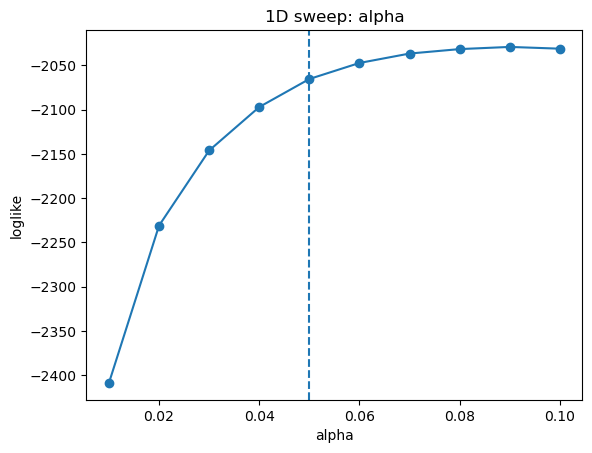

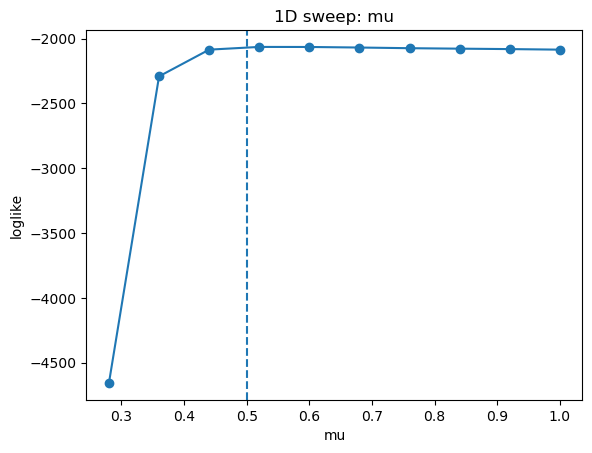

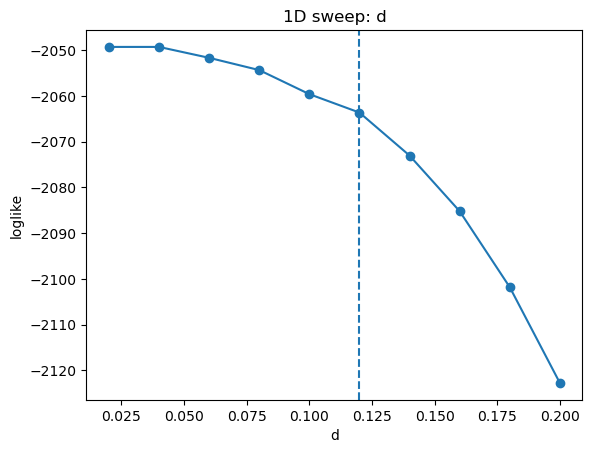

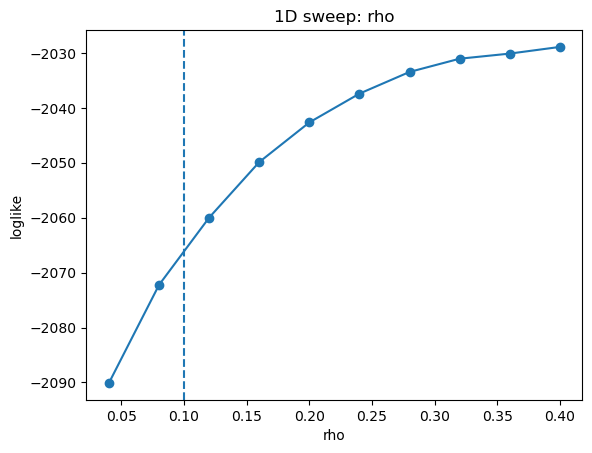

In [6]:
# Plot results
def plot_1d(x, ll, truth_val, xlabel):
    plt.figure()
    plt.plot(x, ll, marker="o")
    plt.axvline(truth_val, linestyle="--")
    plt.xlabel(xlabel)
    plt.ylabel("loglike")
    plt.title(f"1D sweep: {xlabel}")
    plt.show()

plot_1d(x_a, ll_a, ALPHA_TRUE, "alpha")
plot_1d(x_m, ll_m, MU_TRUE,    "mu")
plot_1d(x_d, ll_d, D_TRUE,     "d")
plot_1d(x_r, ll_r, RHO_TRUE,   "rho")

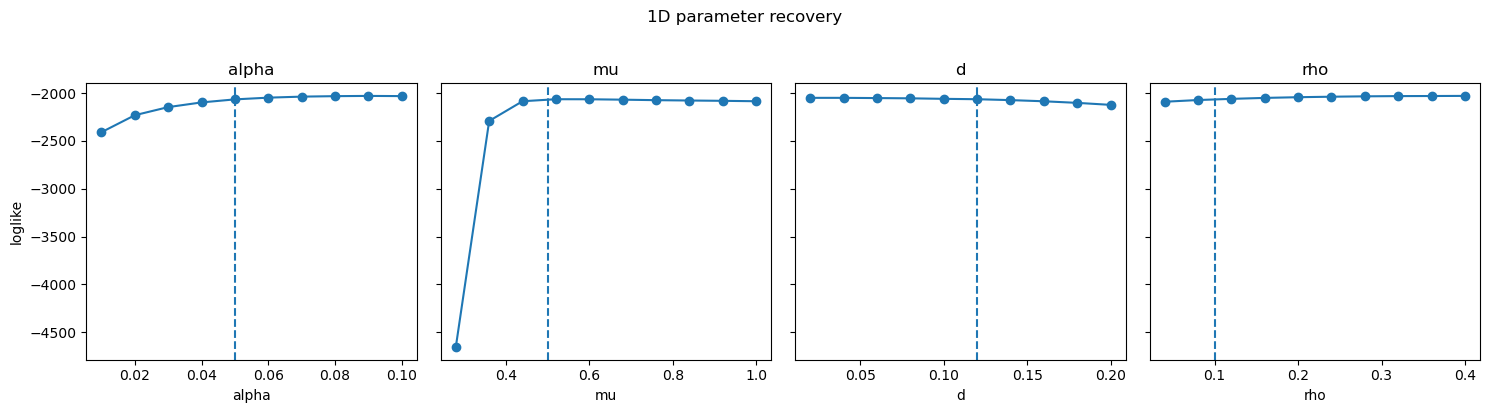

In [7]:
def plot_1d_row(xs, lls, truths, xlabels):
    fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=True)

    for ax, x, ll, truth, xlabel in zip(axes, xs, lls, truths, xlabels):
        ax.plot(x, ll, marker="o")
        ax.axvline(truth, linestyle="--")
        ax.set_xlabel(xlabel)
        ax.set_title(f"{xlabel}")

    axes[0].set_ylabel("loglike")
    fig.suptitle("1D parameter recovery", y=1.02)
    plt.tight_layout()
    plt.show()

plot_1d_row(
    xs=[x_a, x_m, x_d, x_r],
    lls=[ll_a, ll_m, ll_d, ll_r],
    truths=[ALPHA_TRUE, MU_TRUE, D_TRUE, RHO_TRUE],
    xlabels=["alpha", "mu", "d", "rho"],
)


In [8]:
import pandas as pd

os.makedirs("recovery_tests/grid_TL", exist_ok=True)

pd.DataFrame({"alpha": x_a, "loglike": ll_a}).to_csv("recovery_tests/grid_TL/alpha_only.csv", index=False)
pd.DataFrame({"mu":    x_m, "loglike": ll_m}).to_csv("recovery_tests/grid_TL/mu_only.csv",    index=False)
pd.DataFrame({"d":     x_d, "loglike": ll_d}).to_csv("recovery_tests/grid_TL/d_only.csv",     index=False)
pd.DataFrame({"rho":   x_r, "loglike": ll_r}).to_csv("recovery_tests/grid_TL/rho_only.csv",   index=False)

print("Saved CSVs in recovery_tests/grid_TL/")


Saved CSVs in recovery_tests/grid_TL/


In [9]:
import time
import torch

def time_loglike(dataset, theta, label=""):
    # Ensure any previous GPU work is done
    if dataset.device.type == "cuda":
        torch.cuda.synchronize()

    t0 = time.perf_counter()
    ll = dataset.loglike(theta)

    # Force completion so timing is real
    if dataset.device.type == "cuda":
        torch.cuda.synchronize()

    dt = time.perf_counter() - t0
    print(f"{label} loglike took {dt:.3f} s  (value={float(ll.detach().cpu()):.6g})", flush=True)
    return ll, dt


In [10]:
theta = torch.tensor(
    [ALPHA_TRUE, MU_TRUE, D_TRUE, RHO_TRUE],
    device=dataset.device,
    dtype=dataset.kappa_samples.dtype,
)

ll, dt = time_loglike(dataset, theta, label="truth")


truth loglike took 37.609 s  (value=-2064.98)


In [11]:
for i in range(3):
    ll, dt = time_loglike(dataset, theta, label=f"run {i}")


run 0 loglike took 36.455 s  (value=-2065.5)
run 1 loglike took 37.417 s  (value=-2065.85)
run 2 loglike took 36.971 s  (value=-2065.13)


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def plot_1d_row_from_csv(
    csv_paths,
    truths,
    xlabels=None,
):
    """
    Plot 1D likelihood curves from CSVs.

    Parameters
    ----------
    csv_paths : list[str | Path]
        Paths to CSV files, each with columns [param, loglike]
    truths : dict
        Mapping from parameter name -> true value
        e.g. {"alpha": 0.05, "mu": 0.5, "d": 0.02, "rho":0.1}
    xlabels : list[str], optional
        Custom x-axis labels; defaults to parameter names
    """

    fig, axes = plt.subplots(1, len(csv_paths), figsize=(5 * len(csv_paths), 4), sharey=True)

    if len(csv_paths) == 1:
        axes = [axes]

    for i, (ax, csv_path) in enumerate(zip(axes, csv_paths)):
        df = pd.read_csv(csv_path)

        # Infer parameter column (anything not 'loglike')
        param_cols = [c for c in df.columns if c != "loglike"]
        if len(param_cols) != 1:
            raise ValueError(f"{csv_path} must have exactly one parameter column")

        param = param_cols[0]

        x = df[param].values
        ll = df["loglike"].values

        ax.plot(x, ll, marker="o")
        ax.axvline(truths[param], linestyle="--")

        xlabel = xlabels[i] if xlabels is not None else param
        ax.set_xlabel(xlabel)
        ax.set_title(param)

    axes[0].set_ylabel("loglike")
    fig.suptitle("1D parameter recovery", y=1.02)
    plt.tight_layout()
    plt.show()


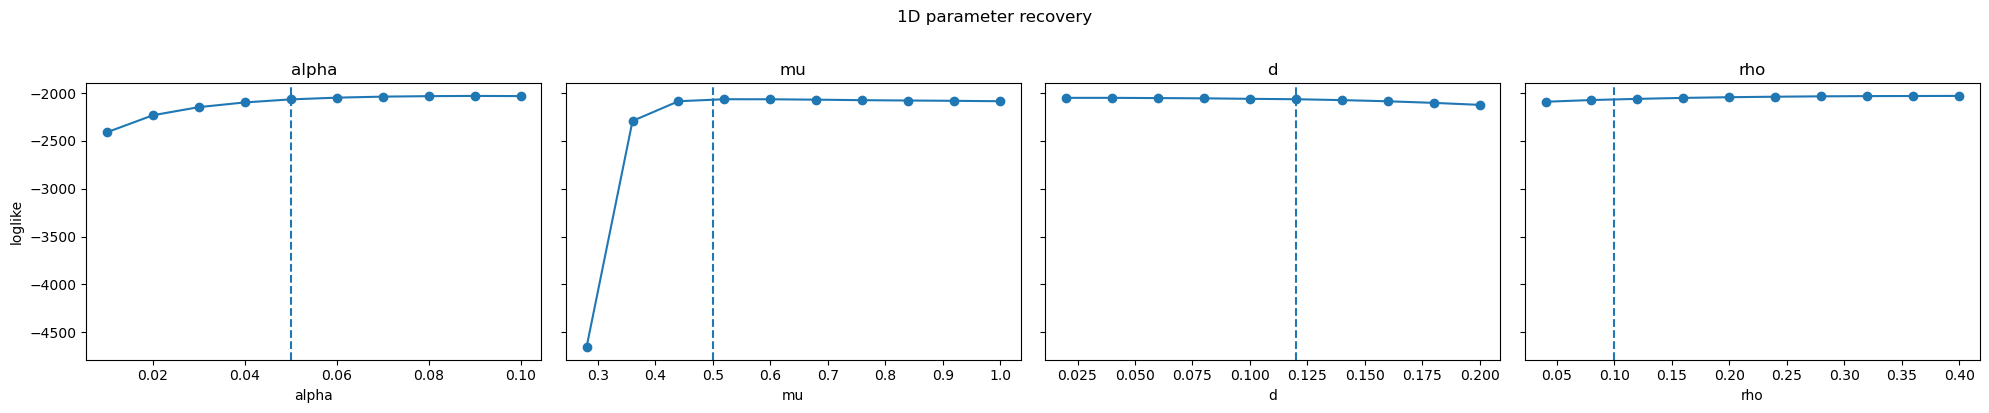

In [13]:
plot_1d_row_from_csv(
    csv_paths=[
        "recovery_tests/grid_TL/alpha_only.csv",
        "recovery_tests/grid_TL/mu_only.csv",
        "recovery_tests/grid_TL/d_only.csv",
        "recovery_tests/grid_TL/rho_only.csv",
    ],
    truths={
        "alpha": 0.05,
        "mu": 0.5,
        "d": 0.12,
        "rho": 0.1,
    },
)
